<a href="https://colab.research.google.com/github/IvanSerem/agro-datascience/blob/main/ProyectoDS_ParteI_Seremczuk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este proyecto trabaja con el dataset “Crop Yield”, proveniente de Kaggle que contiene más de 36.000 registros sobre distintos cultivos y condiciones agrícolas. La base de datos incluye información de 10 tipos de cultivos (trigo, maíz, arroz, soja, caña de azúcar, entre otros), 5 tipos de suelo, variables de nutrientes (N, P, K), pH del suelo, además de factores climáticos como temperatura, humedad y velocidad del viento. También incorpora un índice de calidad del suelo (Soil_Quality) y, lo más importante, el rendimiento de cada cultivo medido en quintales por hectárea, ya que es el termino que mas se adapta en el mundo de la agronomía.

Las fechas de este dataset abarcan desde el 2014 hasta el 2023.

El objetivo del análisis es entender qué factores hacen que una tierra sea más fructífera, combinando la mirada del suelo y el clima. Para eso se plantean preguntas simples pero clave: ¿qué cultivos rinden más en promedio?, ¿qué tipo de suelo es más productivo?, ¿qué tanto influyen la temperatura y la humedad?, ¿los nutrientes N, P y K marcan un punto de corte para suelos fértiles?

La exploración se realiza con un enfoque descriptivo y visual, utilizando análisis univariado, bivariado y multivariado. Con histogramas, boxplots, scatterplots y heatmaps buscamos detectar patrones y relaciones que expliquen por qué ciertos cultivos producen más en determinadas condiciones.

Como primer paso, se revisaron los datos y se comprobó que no existen valores faltantes, lo que permite trabajar directamente sobre la muestra. Luego, a través de gráficos y resúmenes numéricos, se identificaron zonas óptimas de productividad, por ejemplo: temperaturas moderadas cercanas a 20°C con humedades altas (75–80%) y suelos con buenos niveles de nitrógeno, fósforo y potasio.

Este análisis preliminar no pretende predecir todavía, pero sí dejar sentadas las bases para avanzar hacia modelos más sofisticados de machine learning, que permitan recomendar cultivos según el tipo de suelo y las condiciones climáticas.

Objetivo del Proyecto

Este análisis busca identificar patrones que permitan responder a la siguiente pregunta central: ¿es posible determinar, a partir de los valores del suelo y las condiciones climáticas, si una cosecha será fructífera?

El estudio servirá como base para construir, en etapas posteriores, modelos predictivos capaces de anticipar el rendimiento de un cultivo en función de su entorno. De esta manera, será posible tomar decisiones más informadas sobre qué sembrar, dónde sembrar y bajo qué condiciones, con el objetivo de optimizar la producción agrícola y reducir los riesgos asociados a la variabilidad del clima y la calidad del suelo.

Preguntas / Hipótesis de interés

1- ¿Qué cultivos son más productivos en promedio?

2- ¿Cuál es la proporción de productividad promedio por tipo de suelo?

3- ¿Existe una relación positiva entre la calidad del suelo y el rendimiento agrícola?

4- ¿Cómo varía la distribución del rendimiento según el tipo de cultivo??

5- ¿Qué combinación de temperatura y humedad maximiza el rendimiento agrícola?

6- ¿Qué relación tienen los nutrientes principales del suelo (N, P y K) con el rendimiento agrícola, y cuáles son los valores de referencia que marcan suelos fértiles?



In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv('https://raw.githubusercontent.com/IvanSerem/agro-datascience/refs/heads/main/crop_yield_dataset.csv')
df.head()

,Date,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
0,2014-01-01,Wheat,Peaty,5.50,9.440599,80.000000,10.956707,60.5,45.0,31.5,0.000000,22.833333
1,2014-01-01,Corn,Loamy,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,104.871310,66.666667
2,2014-01-01,Rice,Peaty,5.50,12.143099,80.000000,7.227751,71.5,54.0,38.5,0.000000,27.333333
3,2014-01-01,Barley,Sandy,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,58.939796,35.000000
4,2014-01-01,Soybean,Peaty,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,32.970413,22.166667


In [47]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,0


Top 10 cultivos por rendimiento promedio:
   Crop_Type  Crop_Yield
0     Cotton   29.208710
1  Sugarcane   28.694864
2       Rice   28.688229
3       Corn   28.330560
4  Sunflower   27.498513
5     Potato   26.213347
6    Soybean   25.932047
7      Wheat   25.871497
8     Barley   25.552846
9     Tomato   22.794184


/tmp/ipython-input-1155146281.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_crops, x="Crop_Yield", y="Crop_Type", palette="viridis")


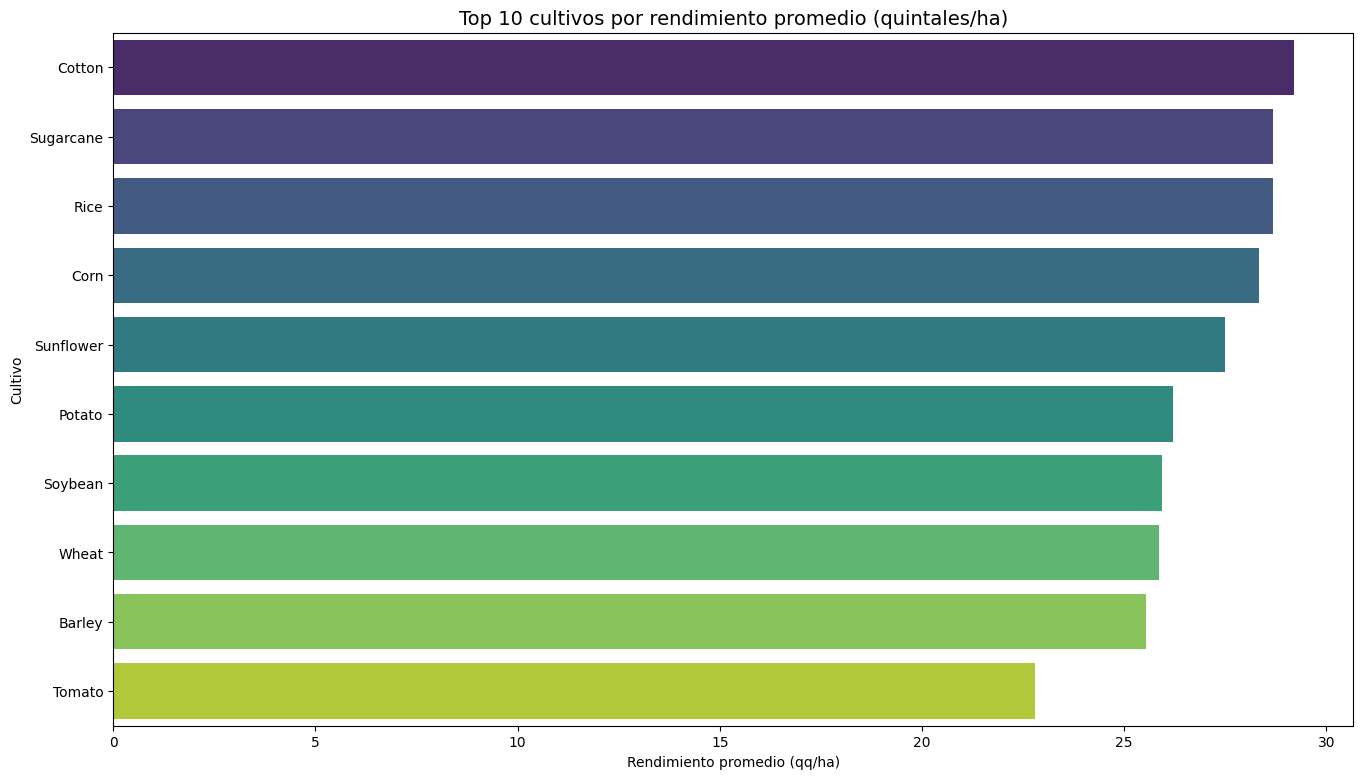

In [48]:
# Top 10 cultivos por rendimiento promedio
top_crops = (
    df.groupby("Crop_Type")["Crop_Yield"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("Top 10 cultivos por rendimiento promedio:")
print(top_crops)

# Gráfico
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,9))
sns.barplot(data=top_crops, x="Crop_Yield", y="Crop_Type", palette="viridis")
plt.title("Top 10 cultivos por rendimiento promedio (quintales/ha)", fontsize=14)
plt.xlabel("Rendimiento promedio (qq/ha)")
plt.ylabel("Cultivo")
plt.show()


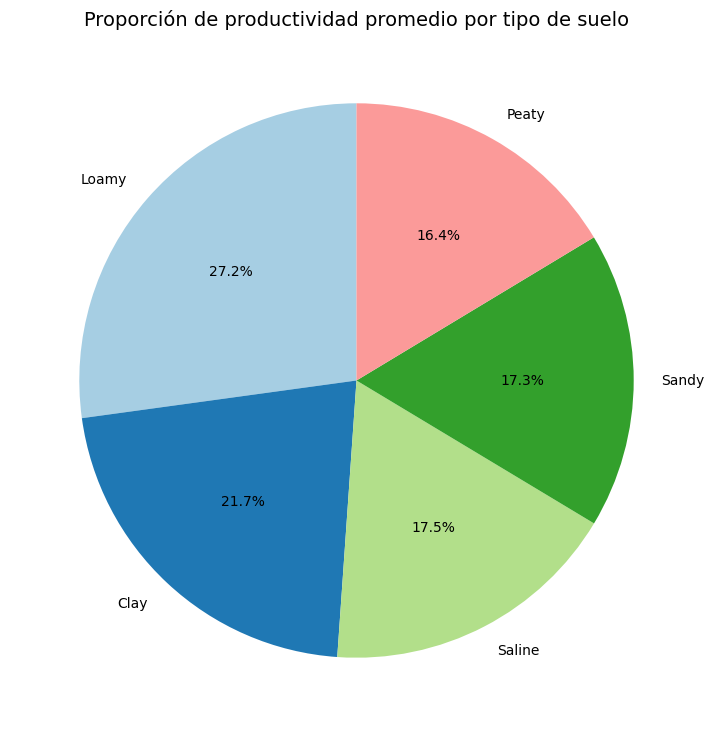

In [49]:
import matplotlib.pyplot as plt

# Rendimiento promedio por tipo de suelo
soil_yield = (
    df.groupby("Soil_Type")["Crop_Yield"]
    .mean()
    .sort_values(ascending=False)
)

# Gráfico de torta
plt.figure(figsize=(16,9))
plt.pie(
    soil_yield,
    labels=soil_yield.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.Paired.colors
)
plt.title("Proporción de productividad promedio por tipo de suelo", fontsize=14)
plt.show()


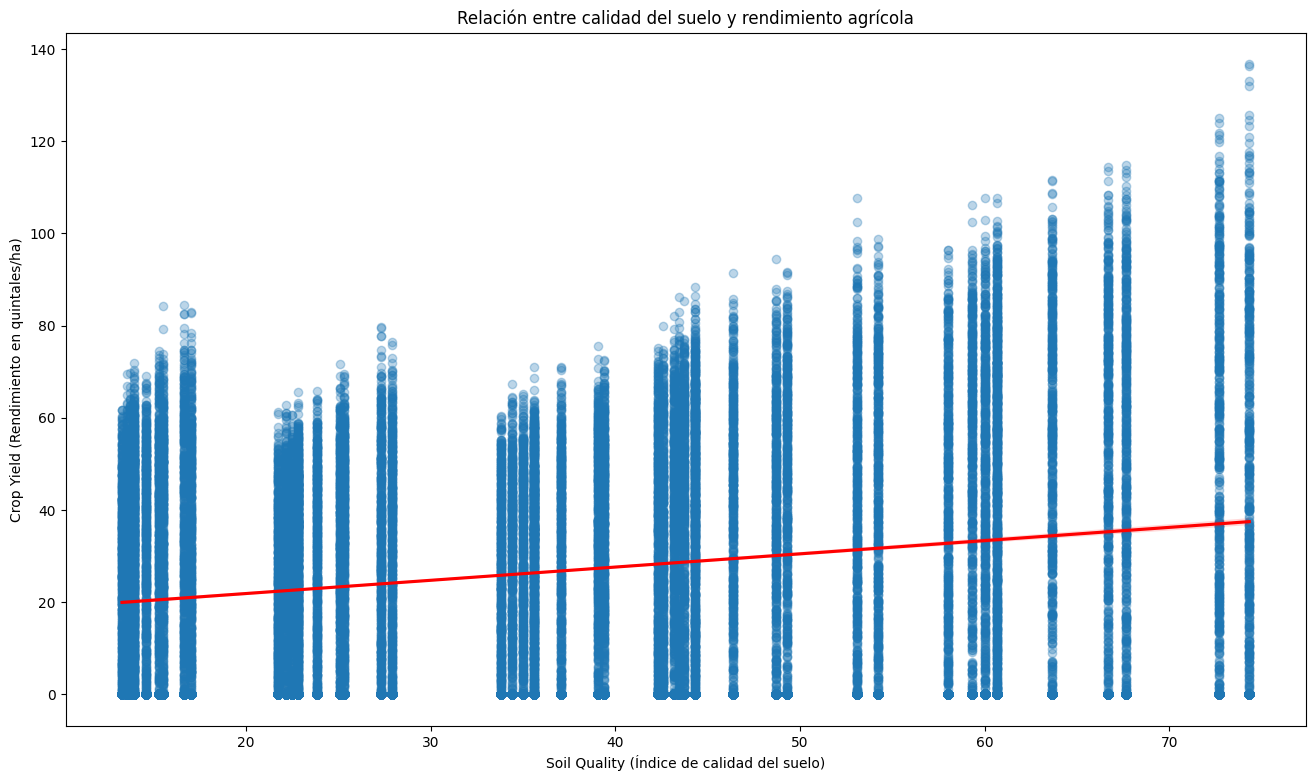

Correlación Soil_Quality ↔ Crop_Yield: 0.197


In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatterplot con línea de regresión
plt.figure(figsize=(16,9))
sns.regplot(
    data=df,
    x="Soil_Quality",
    y="Crop_Yield",
    scatter_kws={"alpha":0.3},   # puntos más transparentes
    line_kws={"color":"red"}     # línea de tendencia en rojo
)
plt.title("Relación entre calidad del suelo y rendimiento agrícola")
plt.xlabel("Soil Quality (Índice de calidad del suelo)")
plt.ylabel("Crop Yield (Rendimiento en quintales/ha)")
plt.show()

# Calcular la correlación
corr = df["Soil_Quality"].corr(df["Crop_Yield"])
print(f"Correlación Soil_Quality ↔ Crop_Yield: {corr:.3f}")


/tmp/ipython-input-2960593950.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


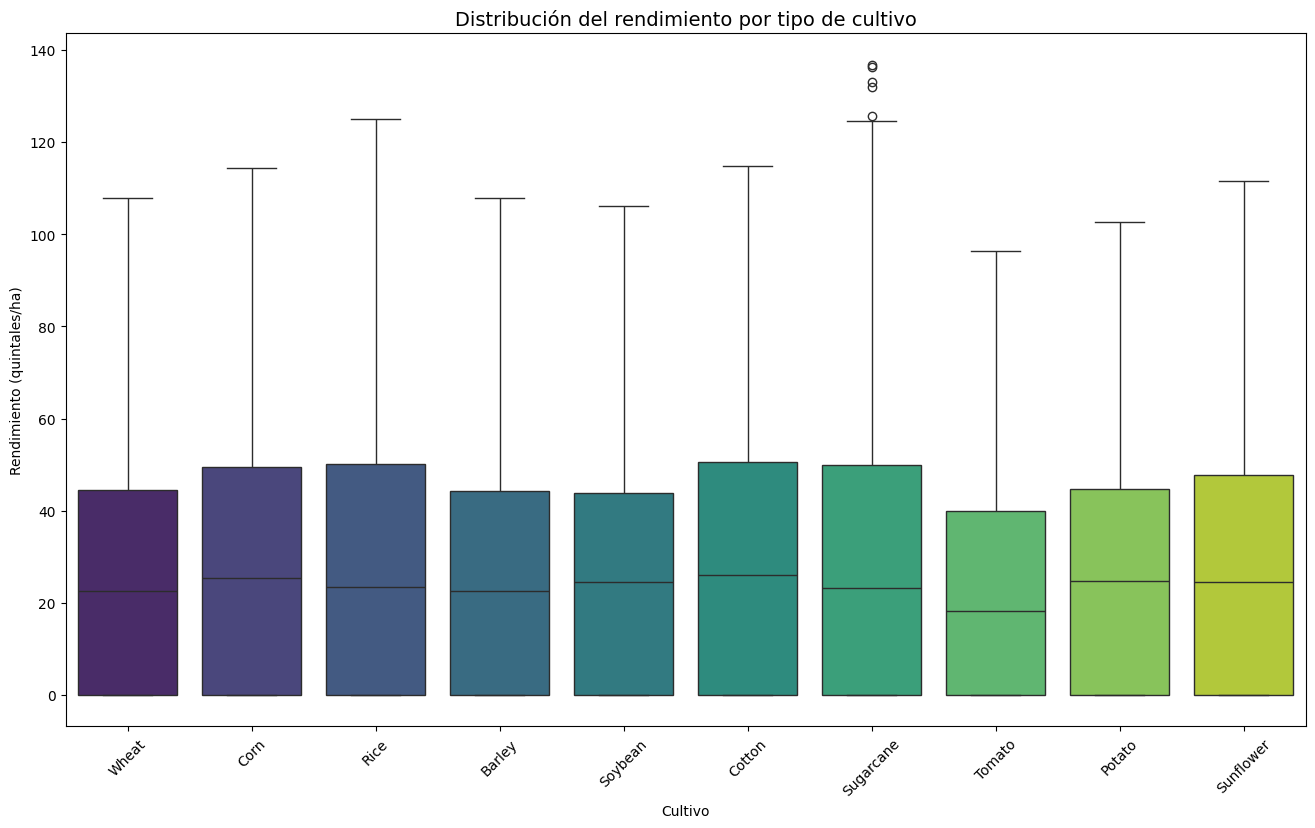

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,9))
sns.boxplot(
    data=df,
    x="Crop_Type",
    y="Crop_Yield",
    palette="viridis"  # paleta de colores bonita
)
plt.title("Distribución del rendimiento por tipo de cultivo", fontsize=14)
plt.xlabel("Cultivo")
plt.ylabel("Rendimiento (quintales/ha)")
plt.xticks(rotation=45)
plt.show()


/tmp/ipython-input-3714311265.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(


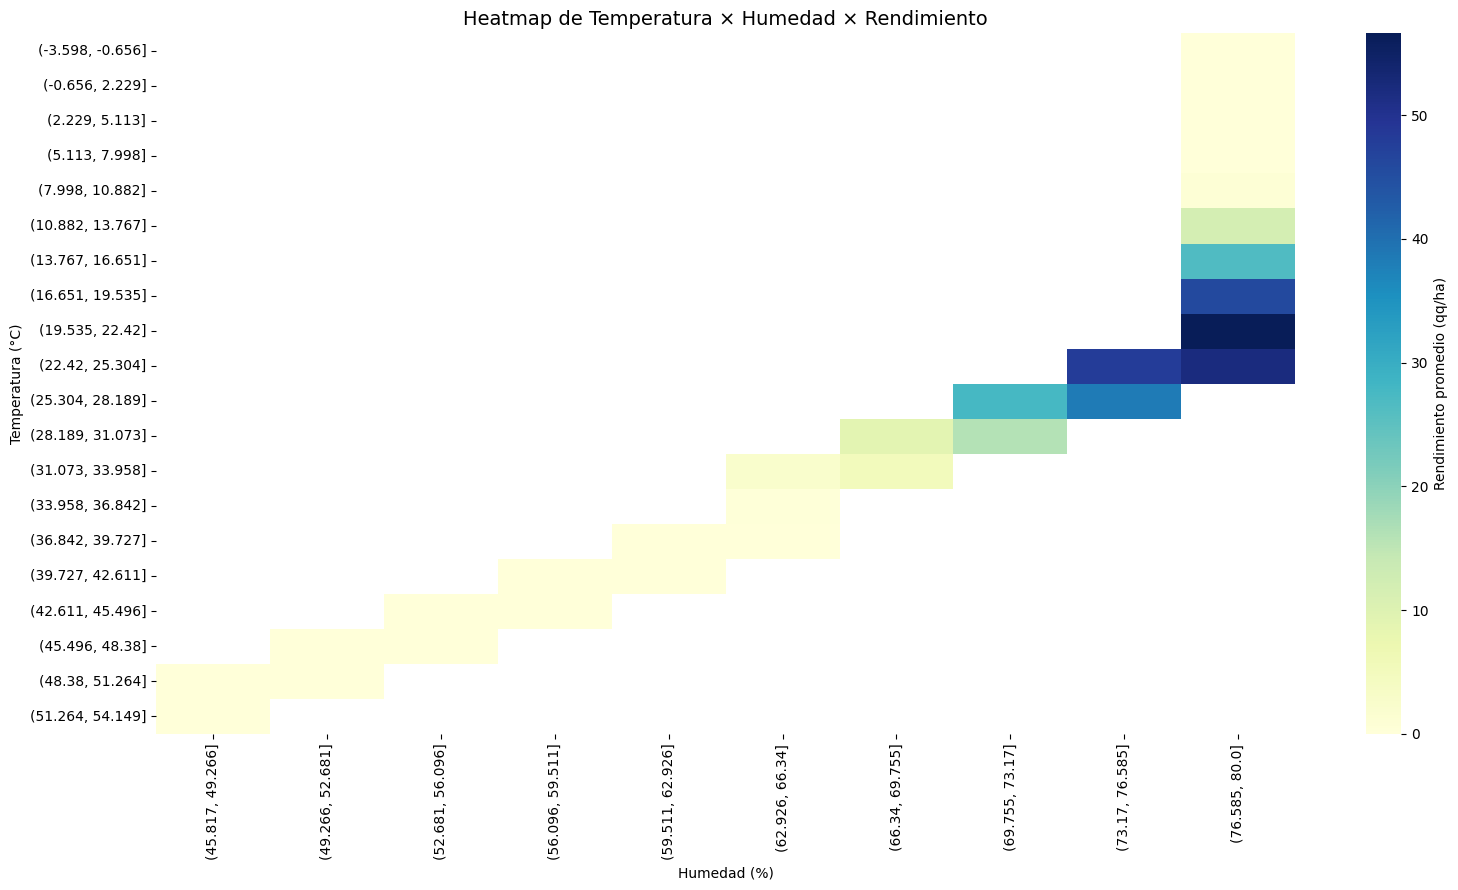

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crear tabla pivote: promedio de rendimiento según temperatura y humedad
pivot_table = df.pivot_table(
    values="Crop_Yield",
    index=pd.cut(df["Temperature"], bins=20),   # dividimos la temperatura en 20 rangos
    columns=pd.cut(df["Humidity"], bins=10),    # dividimos la humedad en 10 rangos
    aggfunc="mean"
)

# Heatmap
plt.figure(figsize=(16,9))
sns.heatmap(
    pivot_table,
    cmap="YlGnBu",  # paleta de colores
    cbar_kws={'label': 'Rendimiento promedio (qq/ha)'}
)
plt.title("Heatmap de Temperatura × Humedad × Rendimiento", fontsize=14)
plt.xlabel("Humedad (%)")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()


Media y Mediana de N, P y K:


,Media,Mediana
N,66.011035,65.0
P,53.014006,54.0
K,42.018250,42.0



Correlación de N, P y K con el rendimiento (Crop_Yield):


,Crop_Yield
N,0.143744
P,0.166614
K,0.155379


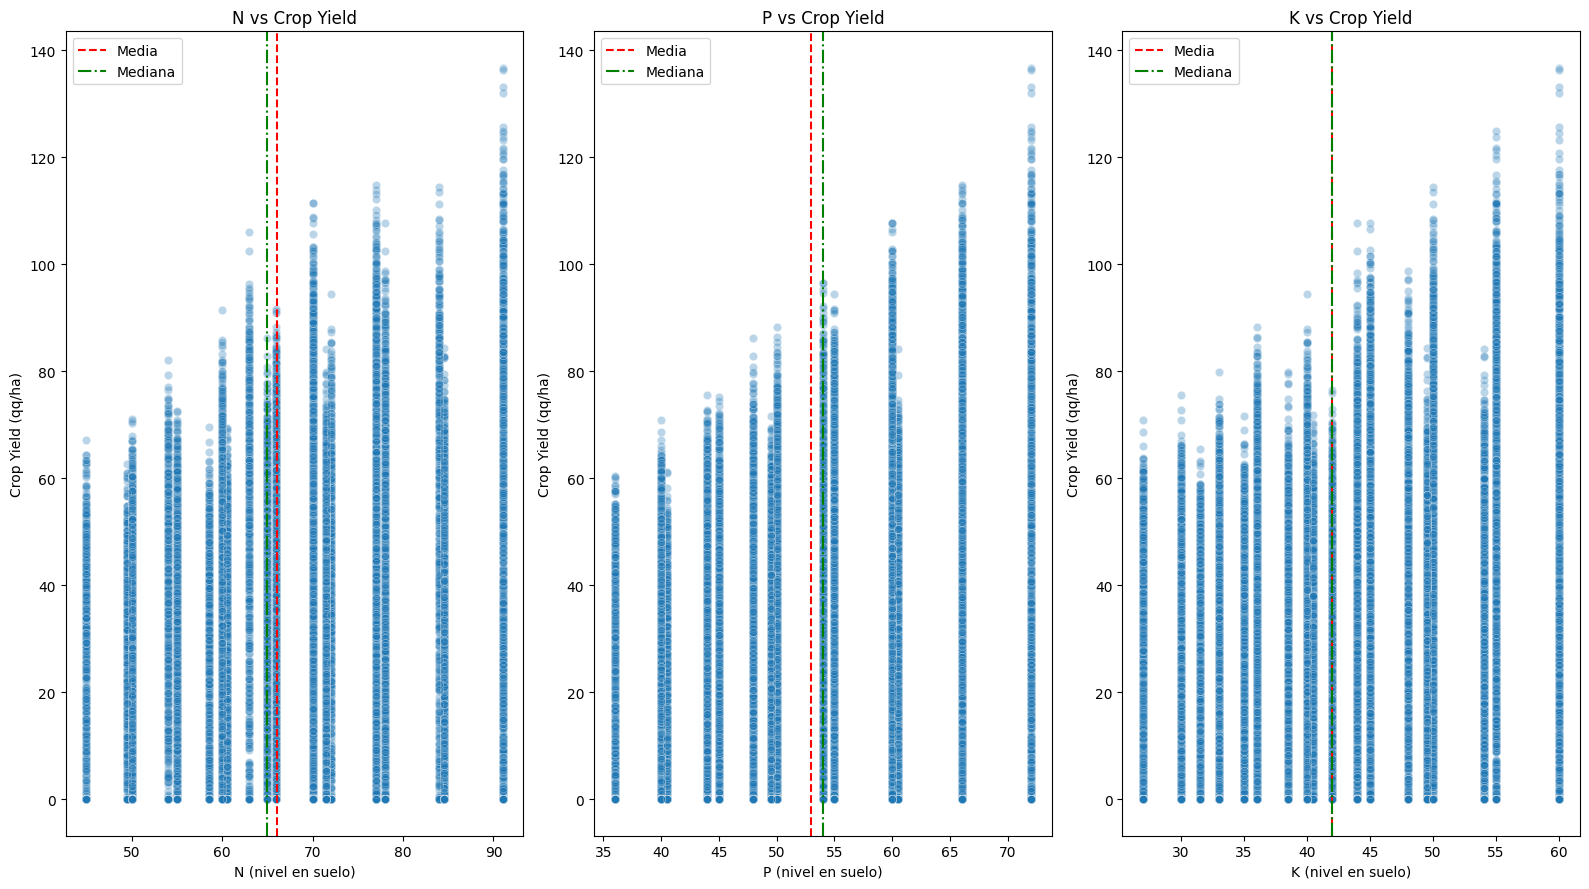

In [53]:
import pandas as pd

# --- Estadísticos descriptivos de N, P, K ---
nutrients_stats = df[["N", "P", "K"]].agg(["mean", "median"]).T
nutrients_stats.columns = ["Media", "Mediana"]
print("Media y Mediana de N, P y K:")
display(nutrients_stats)

# --- Correlaciones con el rendimiento (Crop_Yield) ---
correlations = df[["N", "P", "K", "Crop_Yield"]].corr()["Crop_Yield"].drop("Crop_Yield")
print("\nCorrelación de N, P y K con el rendimiento (Crop_Yield):")
display(correlations)

# --- Comparación visual: distribuciones vs rendimiento ---
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,9))

for i, nutrient in enumerate(["N", "P", "K"], 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(data=df, x=nutrient, y="Crop_Yield", alpha=0.3)
    plt.axvline(df[nutrient].mean(), color="red", linestyle="--", label="Media")
    plt.axvline(df[nutrient].median(), color="green", linestyle="-.", label="Mediana")
    plt.title(f"{nutrient} vs Crop Yield")
    plt.xlabel(f"{nutrient} (nivel en suelo)")
    plt.ylabel("Crop Yield (qq/ha)")
    plt.legend()

plt.tight_layout()
plt.show()



📊 Crop_Yield:
  Outliers detectados: 20
  Rango permitido: [-69.62, 116.04]

📊 N:
  Outliers detectados: 0
  Rango permitido: [39.00, 91.00]

📊 P:
  Outliers detectados: 0
  Rango permitido: [22.50, 82.50]

📊 K:
  Outliers detectados: 0
  Rango permitido: [13.25, 71.25]

📊 Temperature:
  Outliers detectados: 18
  Rango permitido: [-2.46, 49.88]

📊 Humidity:
  Outliers detectados: 161
  Rango permitido: [54.36, 95.38]

📊 Wind_Speed:
  Outliers detectados: 222
  Rango permitido: [1.91, 18.12]

📊 Soil_Quality:
  Outliers detectados: 0
  Rango permitido: [-17.69, 89.48]


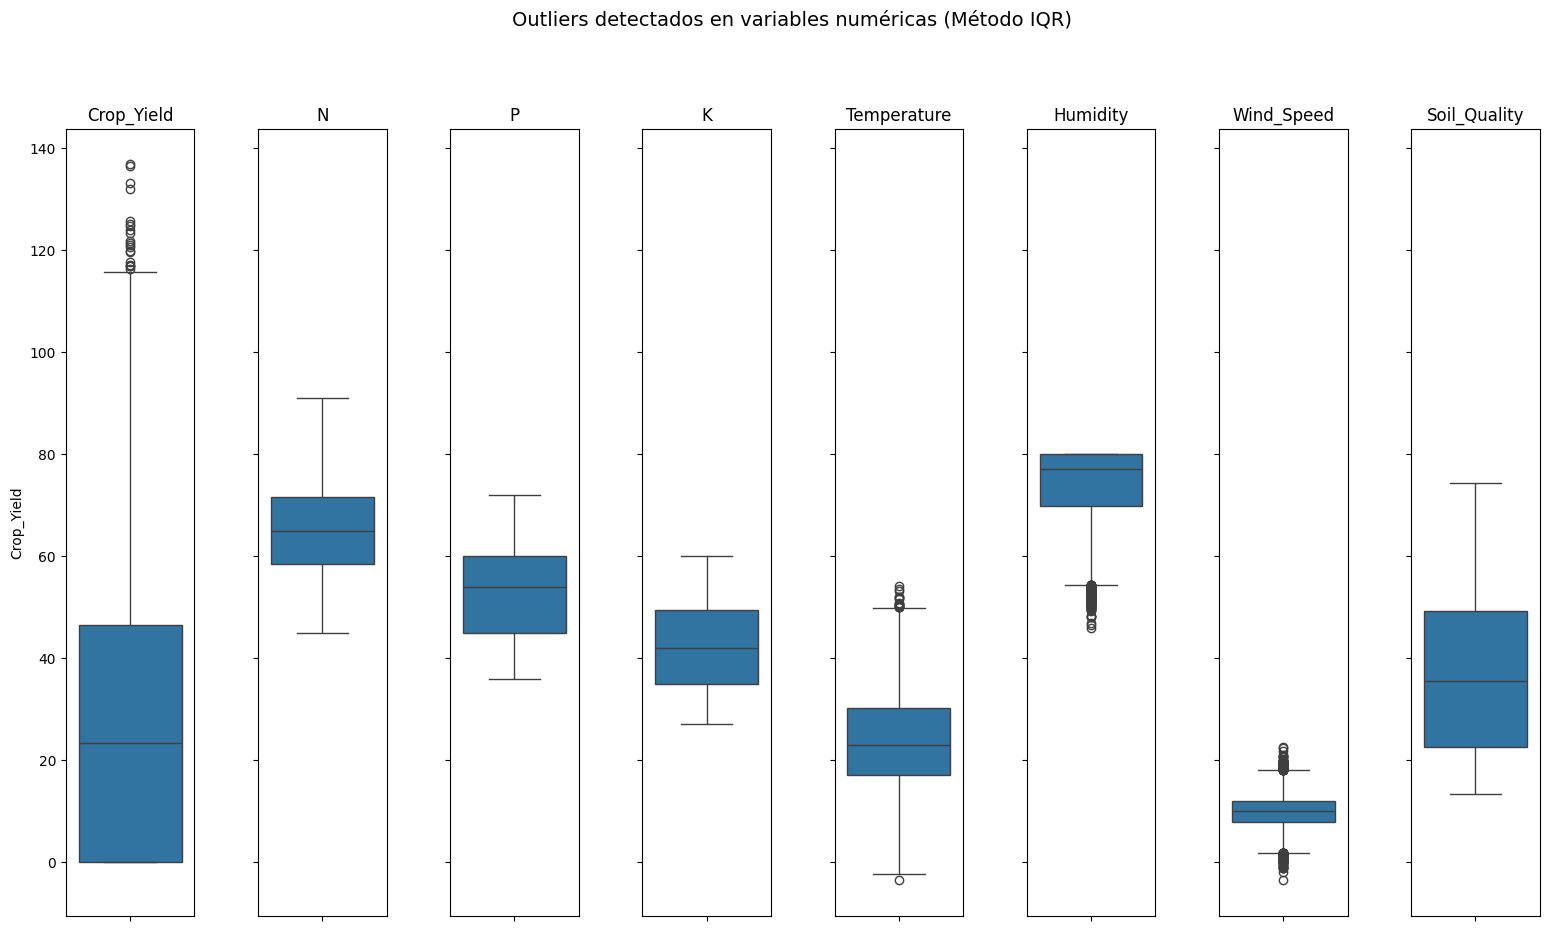

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Función IQR ---
def detect_outliers_iqr(data, column, threshold=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# --- Columnas numéricas (ajustar según tu dataset) ---
numeric_cols = ["Crop_Yield", "N", "P", "K", "Temperature", "Humidity", "Wind_Speed", "Soil_Quality"]

# --- Figura de boxplots ---
fig, axes = plt.subplots(nrows=1, ncols=len(numeric_cols), figsize=(16, 9), sharey=True)
plt.tight_layout(pad=3.0)

iqr_outliers = {}

for i, col in enumerate(numeric_cols):
    if col in df.columns:  # seguridad por si falta alguna
        # Detectar outliers
        outliers, lb, ub = detect_outliers_iqr(df, col)
        iqr_outliers[col] = outliers

        print(f"\n📊 {col}:")
        print(f"  Outliers detectados: {outliers.shape[0]}")
        print(f"  Rango permitido: [{lb:.2f}, {ub:.2f}]")

        # Boxplot
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(f'{col}')
        axes[i].set_xlabel("")

plt.suptitle('Outliers detectados en variables numéricas (Método IQR)', y=1.08, fontsize=14)
plt.show()


Conclusiones Preliminares

-Los cultivos más productivos en promedio fueron algodón, caña de azúcar y arroz, mientras que tomate y cebada se ubicaron en el extremo inferior.

-Entre los tipos de suelo, el Loamy y Clay concentran la mayor proporción de productividad, confirmando que son los más fértiles en este dataset.

-Existe una relación positiva entre el índice de calidad del suelo y el rendimiento: a mayor calidad, mayor producción, aunque con variabilidad según el cultivo.

-La distribución por cultivo muestra diferencias importantes en estabilidad: mientras que caña de azúcar presenta altos rendimientos con variabilidad, cultivos como trigo o tomate son más consistentes pero con menores valores.

-En cuanto a las condiciones climáticas, el heatmap de temperatura y humedad deja claro que el punto óptimo se alcanza en temperaturas moderadas (≈20°C) combinadas con humedades altas (≈76–80%).

-Los nutrientes del suelo (N=65, P=54, K=42 como valores de referencia en mediana) actúan como umbrales de fertilidad: suelos con valores iguales o superiores tienden a generar mejores cosechas.

-En lo que repespecta a nuestros método del Rango Intercuartílico (IQR), sacamos en conclucion que nuestros datos se ensucian en los asuntos de clima y humedad. A esto lo podemos atribuir a errores en los sensonres de precipitacion o a ciertas regiones que pueden estar en climas muy extremos.

Los análisis confirman que la productividad agrícola no depende de un solo factor, sino de la combinación entre el tipo de cultivo, el suelo (su fertilidad y calidad) y el clima (temperatura + humedad). Estas observaciones iniciales abren la puerta a desarrollar un modelo predictivo que pueda anticipar el rendimiento en función de estas condiciones.

--------------------------------------------------------------------------------


"Preparacion" de los datos

Limpieza de los datos

In [55]:
# Valores faltantes

In [56]:
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])  # debería no imprimir nada
print("Total NA:", df.isna().sum().sum())  # debería dar 0


Series([], dtype: int64)
Total NA: 0


In [57]:
# Outliers

Outliers de Temperature ajustados con método IQR 
Outliers de Humidity ajustados con método IQR 
Outliers de Wind_Speed ajustados con método IQR 


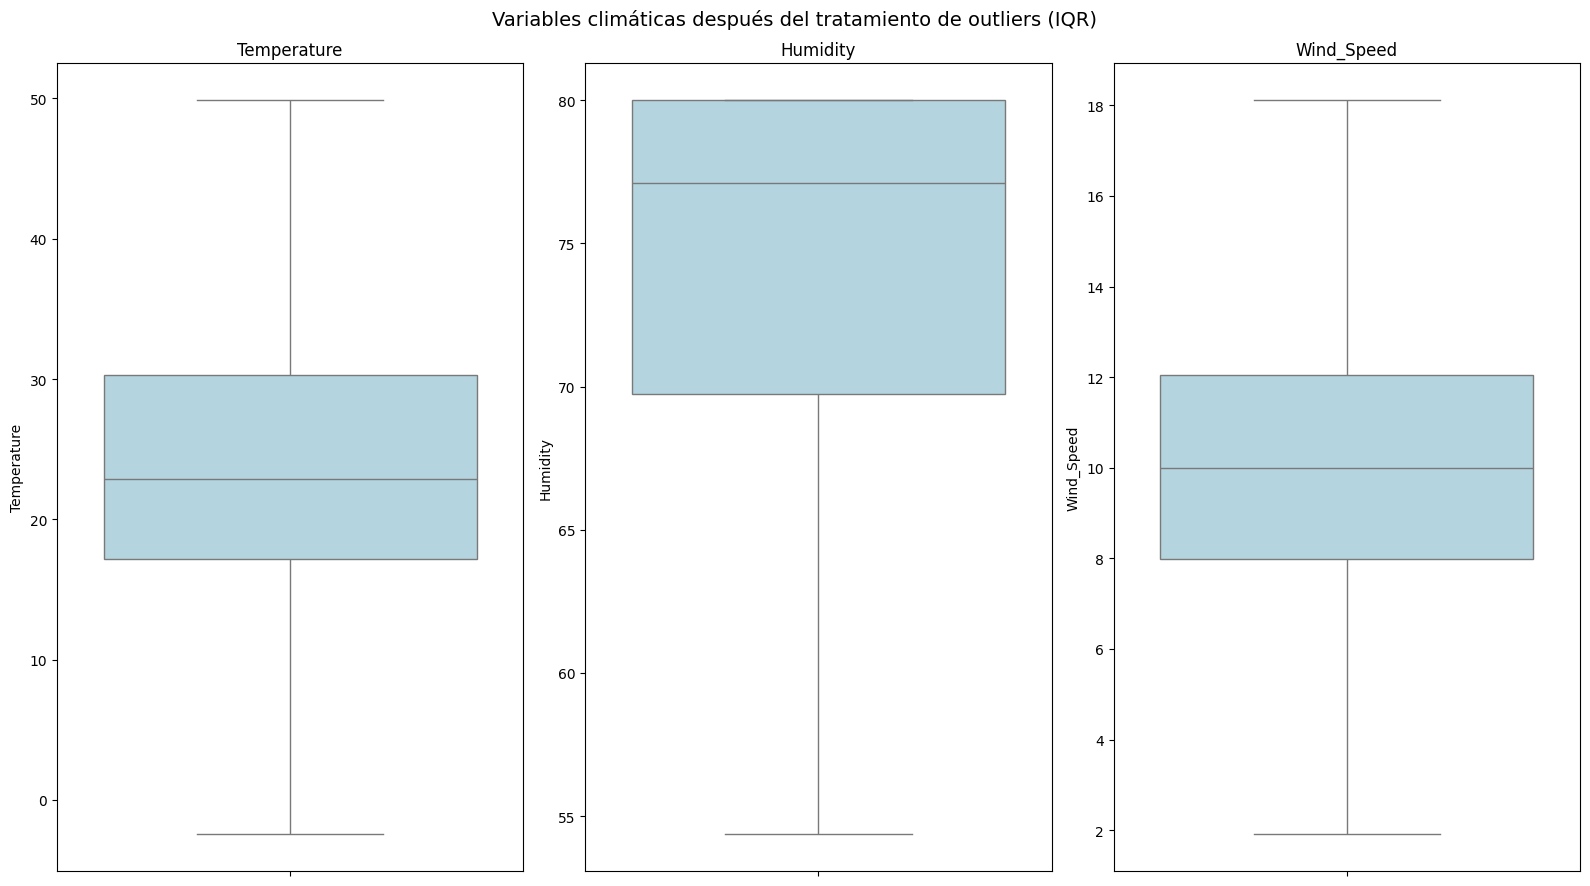

In [58]:
# =====================================
# Eliminación / corrección de outliers
# =====================================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Función general para capping con IQR ---
def cap_outliers_iqr(data, column, threshold=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - threshold * IQR
    upper = Q3 + threshold * IQR
    # Reemplazamos los valores fuera del rango por los límites
    data[column] = np.clip(data[column], lower, upper)
    return data

# --- Aplicar solo a las variables con outliers confirmados ---
climate_cols = ['Temperature', 'Humidity', 'Wind_Speed']

for col in climate_cols:
    df = cap_outliers_iqr(df, col)
    print(f"Outliers de {col} ajustados con método IQR ")

# --- Visualización: comparación después del ajuste ---
fig, axes = plt.subplots(1, 3, figsize=(16, 9))
for i, col in enumerate(climate_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col)
plt.suptitle("Variables climáticas después del tratamiento de outliers (IQR)", fontsize=14)
plt.tight_layout()
plt.show()


In [59]:
# =====================================
# Verificación estadística post-limpieza
# =====================================

print("Resumen estadístico de variables climáticas (después del tratamiento de outliers):\n")
display(df[['Temperature', 'Humidity', 'Wind_Speed']].describe().T)

# También verificamos que no haya valores fuera de los límites IQR esperados
print("\nRangos actuales:")
for col in ['Temperature', 'Humidity', 'Wind_Speed']:
    min_val, max_val = df[col].min(), df[col].max()
    print(f"{col:12} → min: {min_val:.2f} | max: {max_val:.2f}")


Resumen estadístico de variables climáticas (después del tratamiento de outliers):



,count,mean,std,min,25%,50%,75%,max
Temperature,36520.0,23.813393,8.918489,-2.460768,17.168542,22.902987,30.254748,49.884058
Humidity,36520.0,74.265312,6.739793,54.363130,69.745252,77.097013,80.000000,80.000000
Wind_Speed,36520.0,10.020081,2.981811,1.906859,7.985872,10.000299,12.038546,18.117559



Rangos actuales:
Temperature  → min: -2.46 | max: 49.88
Humidity     → min: 54.36 | max: 80.00
Wind_Speed   → min: 1.91 | max: 18.12


In [60]:
# Datos duplicado

In [61]:
# =====================================
# Detección y eliminación de duplicados
# =====================================

# Contar duplicados antes de eliminar
duplicados = df.duplicated().sum()
print(f"🔍 Registros duplicados detectados: {duplicados}")

# Si hay duplicados, los eliminamos
if duplicados > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicados eliminados ")
else:
    print("No se encontraron duplicados ")

# Verificar dimensiones finales
print(f"Dimensiones actuales del dataset: {df.shape}")


🔍 Registros duplicados detectados: 0
No se encontraron duplicados 
Dimensiones actuales del dataset: (36520, 12)


Transformacion de los datos

In [62]:
# Codificacion de variables categoricas

In [63]:
# =====================================
# TRANSFORMACIÓN DE VARIABLES CATEGÓRICAS
# =====================================

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Variables categóricas a transformar
cat_cols = ['Crop_Type', 'Soil_Type']

# Definimos el codificador
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Aplicamos el encoder
encoded_data = encoder.fit_transform(df[cat_cols])

# Obtenemos los nombres de las columnas nuevas
encoded_cols = encoder.get_feature_names_out(cat_cols)

# Convertimos a DataFrame
encoded_df = pd.DataFrame(encoded_data, columns=encoded_cols, index=df.index)

# Concatenamos con las numéricas originales (sin las categóricas originales)
df_encoded = pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1)

print("✅ Transformación completada. Dimensiones finales:", df_encoded.shape)
display(df_encoded.head())


✅ Transformación completada. Dimensiones finales: (36520, 25)


,Date,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality,...,Crop_Type_Soybean,Crop_Type_Sugarcane,Crop_Type_Sunflower,Crop_Type_Tomato,Crop_Type_Wheat,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Peaty,Soil_Type_Saline,Soil_Type_Sandy
0,2014-01-01,5.50,9.440599,80.000000,10.956707,60.5,45.0,31.5,0.000000,22.833333,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,2014-01-01,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,104.871310,66.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2014-01-01,5.50,12.143099,80.000000,7.227751,71.5,54.0,38.5,0.000000,27.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2014-01-01,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,58.939796,35.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2014-01-01,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,32.970413,22.166667,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Dimensiones de X: (36520, 23)
Dimensiones de y: (36520,)
=== Ranking por importancia estadística (SelectKBest) ===


,Variable,Score (F_regression)
2,Humidity,13015.737365
1,Temperature,3306.290778
7,Soil_Quality,1481.811167
19,Soil_Type_Loamy,1324.527200
5,P,1042.688059
6,K,903.454614
4,N,770.461767
20,Soil_Type_Peaty,330.835964
22,Soil_Type_Sandy,186.835972
21,Soil_Type_Saline,159.068366


=== Importancia según Random Forest ===


,Variable,Importancia (RF)
1,Temperature,0.565965
2,Humidity,0.166925
7,Soil_Quality,0.088990
16,Crop_Type_Tomato,0.040887
12,Crop_Type_Rice,0.038316
14,Crop_Type_Sugarcane,0.037988
4,N,0.025100
5,P,0.010704
9,Crop_Type_Corn,0.009448
3,Wind_Speed,0.008226


/tmp/ipython-input-2145735336.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


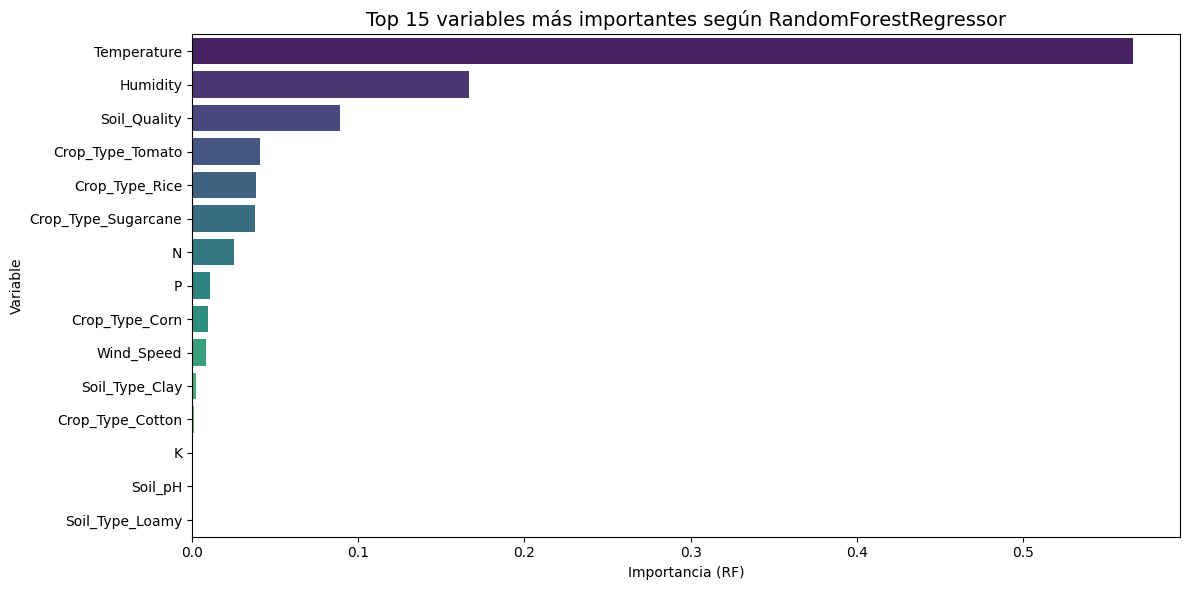


🔍 Interpretación:
- El ranking de SelectKBest muestra qué variables tienen correlación estadística más alta con el rendimiento.
- El ranking de RandomForest indica cuáles influyen más en la predicción del rendimiento según un modelo no lineal.
- Si ambas coinciden (por ejemplo: Humidity, N, P, K, Temperature, Soil_Quality),
  podemos concluir que esas variables son las más relevantes para explicar la productividad agrícola.



In [64]:
# =====================================
# FEATURE SELECTION - SELECCIÓN DE VARIABLES RELEVANTES
# =====================================

from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------
# 1️⃣ Separar variables predictoras (X) y objetivo (y)
# Eliminamos 'Date' porque es texto y no aporta al modelo
# -------------------------------------
X = df_encoded.drop(columns=['Crop_Yield', 'Date'])
y = df_encoded['Crop_Yield']

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

# -------------------------------------
# 2️⃣ Selección estadística (SelectKBest con f_regression)
# -------------------------------------
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

# Crear DataFrame con puntuaciones
scores = pd.DataFrame({
    'Variable': X.columns,
    'Score (F_regression)': selector.scores_
}).sort_values(by='Score (F_regression)', ascending=False)

print("=== Ranking por importancia estadística (SelectKBest) ===")
display(scores.head(10))

# -------------------------------------
# 3️⃣ Importancia según modelo Random Forest Regressor
# -------------------------------------
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia (RF)': rf.feature_importances_
}).sort_values(by='Importancia (RF)', ascending=False)

print("=== Importancia según Random Forest ===")
display(importances.head(10))

# -------------------------------------
# 4️⃣ Visualización comparativa
# -------------------------------------
plt.figure(figsize=(12,6))
sns.barplot(
    data=importances.head(15),
    x='Importancia (RF)',
    y='Variable',
    palette='viridis'
)
plt.title('Top 15 variables más importantes según RandomForestRegressor', fontsize=14)
plt.tight_layout()
plt.show()

# -------------------------------------
# 5️⃣ Resumen de interpretación
# -------------------------------------
print("""
🔍 Interpretación:
- El ranking de SelectKBest muestra qué variables tienen correlación estadística más alta con el rendimiento.
- El ranking de RandomForest indica cuáles influyen más en la predicción del rendimiento según un modelo no lineal.
- Si ambas coinciden (por ejemplo: Humidity, N, P, K, Temperature, Soil_Quality),
  podemos concluir que esas variables son las más relevantes para explicar la productividad agrícola.
""")
